In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("Reddit_Data.csv")
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


## Data Cleaning

In [3]:
df["category"].nunique()

3

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   clean_comment  37149 non-null  str  
 1   category       37249 non-null  int64
dtypes: int64(1), str(1)
memory usage: 582.1 KB


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

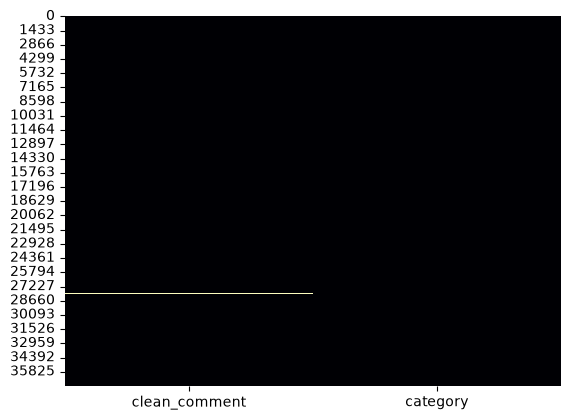

In [6]:
sns.heatmap(df.isnull(),cmap = 'magma',cbar = False)

In [7]:
df.isnull().sum()

clean_comment    100
category           0
dtype: int64

In [8]:
df.dropna(inplace=True)

In [9]:
df.duplicated().sum()

np.int64(350)

In [10]:
df[df.duplicated()]

,clean_comment,category
375,,0
392,,0
617,aurum mom,0
651,,0
1222,,0
...,...,...
36915,who won,0
37044,,0
37125,hari,0
37158,top kek,1


In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df[df["clean_comment"].str.strip() == ""]

,clean_comment,category
181,,0
4432,\n,0
10592,,0
16173,,0
32149,\n,0
34959,,0


In [14]:
df = df[~(df["clean_comment"].str.strip() == "")]

In [15]:
df["clean_comment"] = df["clean_comment"].str.lower()

In [16]:
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [17]:
df["clean_comment"] = df["clean_comment"].str.strip()

In [18]:
import re
url_pattern = re.compile(r"https?://\S+|www\.\S+")
df["clean_comment"] = df["clean_comment"].apply(lambda x: url_pattern.sub(" ", x))

In [19]:
comment_with_nextline = df[df["clean_comment"].str.contains("\n")]     # contatins
comment_with_nextline.head()

,clean_comment,category
448,what missing jpg\nand why this brilliant edit ...,1
781,india has been ruined congress and populist sc...,-1
847,like aap for its stand corruption and making p...,-1
871,reduced trade\ndeficit stronger rupee aren the...,0
1354,amsa press conference australian maritime safe...,1


In [20]:
df["clean_comment"] = df["clean_comment"].apply(lambda x: x.replace("\n"," "))

In [21]:
df[df["clean_comment"].str.contains("\n")]

,clean_comment,category


## EDA

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='category', ylabel='count'>

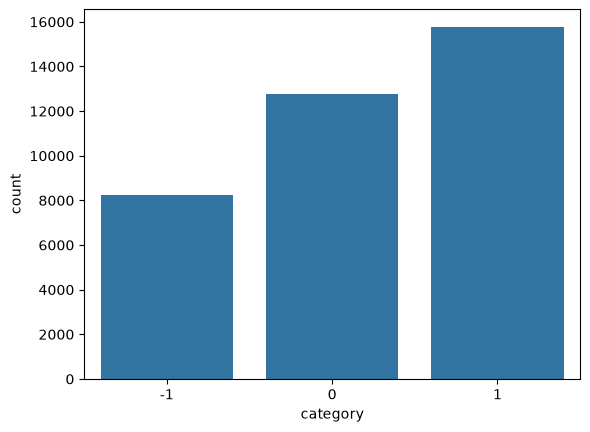

In [23]:
sns.countplot(data = df, x = "category")

In [24]:
(df["category"].value_counts()/df["category"].value_counts().sum()).round(2)

category
 1    0.43
 0    0.35
-1    0.22
Name: count, dtype: float64

In [25]:
df["word_count"] = df["clean_comment"].apply(lambda x: len(x.split()))

In [26]:
df.head()

,clean_comment,category,word_count
0,family mormon have never tried explain them th...,1,39
1,buddhism has very much lot compatible with chr...,1,196
2,seriously don say thing first all they won get...,-1,86
3,what you have learned yours and only yours wha...,0,29
4,for your own benefit you may want read living ...,1,112


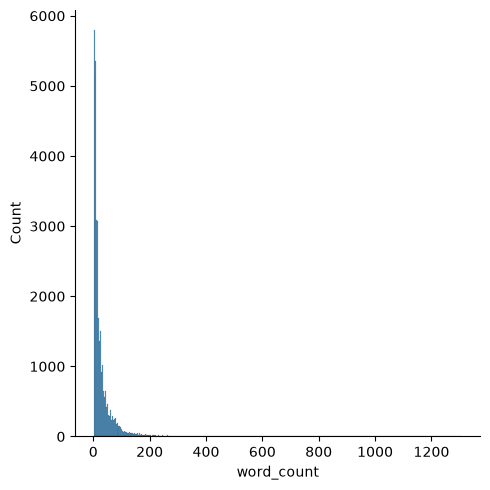

In [27]:
sns.displot(df["word_count"])

In [28]:
df[df["category"] == 1]["word_count"]

0         39
1        196
4        112
6        155
9         31
        ... 
37233     21
37236     88
37240      8
37245     19
37247      2
Name: word_count, Length: 15771, dtype: int64

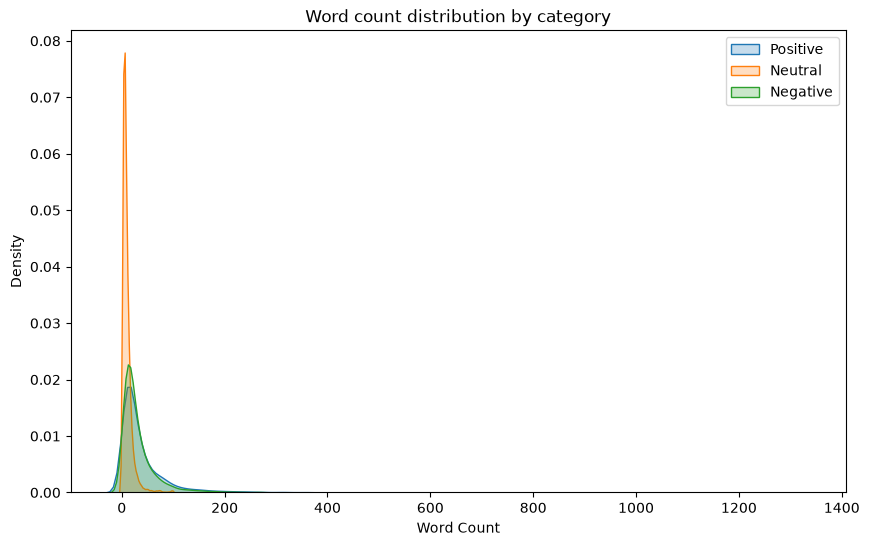

In [29]:
plt.figure(figsize=(10,6))

sns.kdeplot(df[df["category"] == 1]["word_count"], label="Positive",fill =True)
sns.kdeplot(df[df["category"] == 0]["word_count"], label="Neutral",fill =True)
sns.kdeplot(df[df["category"] == -1]["word_count"], label="Negative",fill =True)

plt.title("Word count distribution by category")
plt.xlabel("Word Count")
plt.ylabel("Density")
plt.legend()
plt.show()

Text(0, 0.5, 'Word Count')

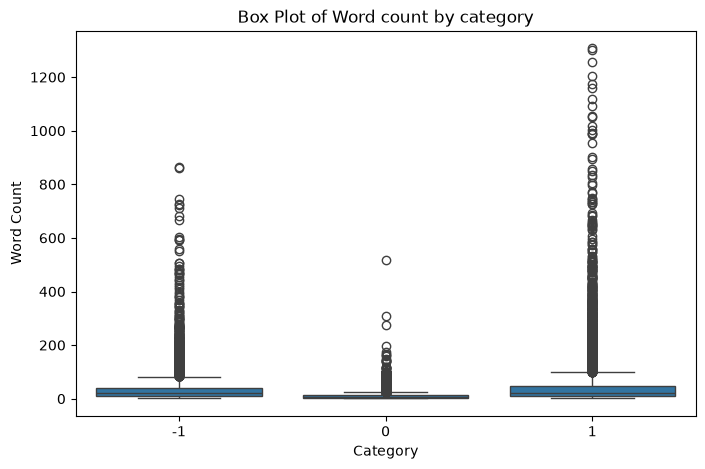

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(df,x="category",y="word_count")
plt.title("Box Plot of Word count by category")
plt.xlabel("Category")
plt.ylabel("Word Count")

Text(0, 0.5, 'Word Count')

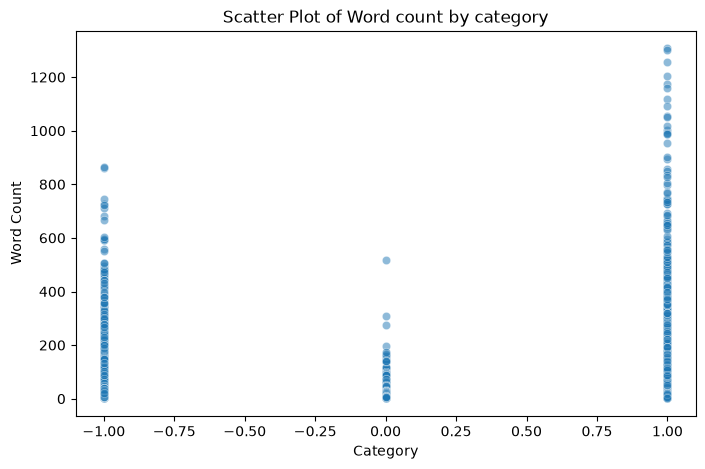

In [31]:
plt.figure(figsize=(8,5))
sns.scatterplot(df,x="category",y="word_count",alpha = 0.5)
plt.title("Scatter Plot of Word count by category")
plt.xlabel("Category")
plt.ylabel("Word Count")

In [32]:
import nltk
from nltk.corpus import stopwords

STOPWORDS = set(stopwords.words("english"))

In [33]:
df["num_stopwords"] = df["clean_comment"].apply(lambda x : len([word for word in x.split() if word in STOPWORDS]))

In [34]:
df.head()

,clean_comment,category,word_count,num_stopwords
0,family mormon have never tried explain them th...,1,39,13
1,buddhism has very much lot compatible with chr...,1,196,59
2,seriously don say thing first all they won get...,-1,86,40
3,what you have learned yours and only yours wha...,0,29,15
4,for your own benefit you may want read living ...,1,112,45


<Axes: xlabel='num_stopwords', ylabel='Count'>

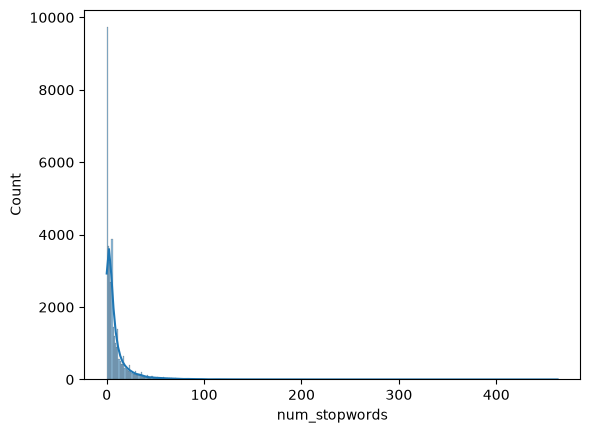

In [35]:
sns.histplot(df["num_stopwords"], kde=True)

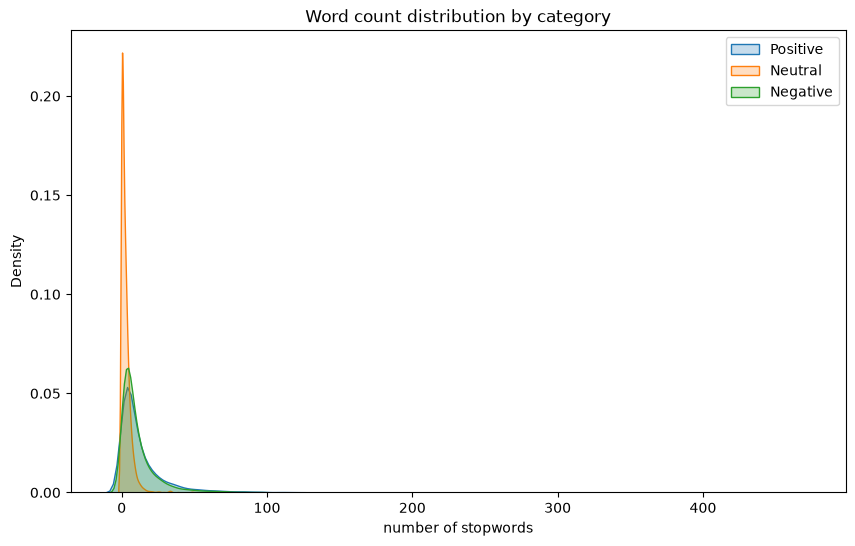

In [36]:
plt.figure(figsize=(10,6))

sns.kdeplot(df[df["category"] == 1]["num_stopwords"], label="Positive",fill =True)
sns.kdeplot(df[df["category"] == 0]["num_stopwords"], label="Neutral",fill =True)
sns.kdeplot(df[df["category"] == -1]["num_stopwords"], label="Negative",fill =True)

plt.title("Word count distribution by category")
plt.xlabel("number of stopwords")
plt.ylabel("Density")
plt.legend()
plt.show()

C:\Users\SAYAN\AppData\Local\Temp\ipykernel_14320\2285541590.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(top_25_df, x= "count", y="stopwords",palette="viridis")


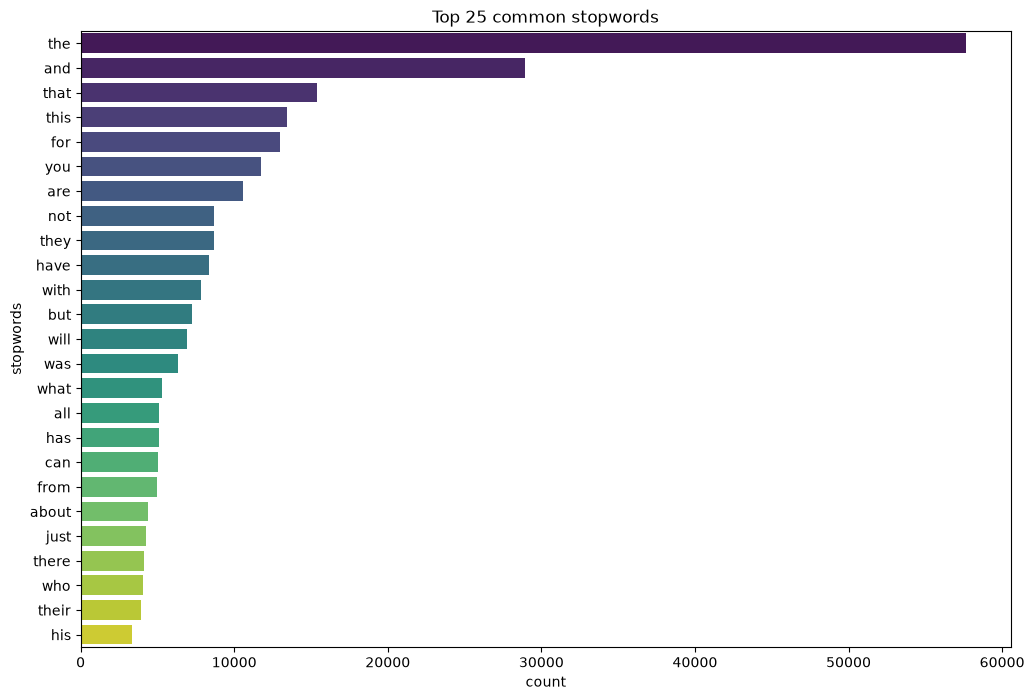

In [37]:
from collections import Counter

all_stopwords = [word for comment in df["clean_comment"] for word in comment.split() if word in STOPWORDS]

most_25_common_stopwords = Counter(all_stopwords).most_common(25)
top_25_df = pd.DataFrame(most_25_common_stopwords, columns= ["stopwords","count"])

plt.figure(figsize=(12,8))
sns.barplot(top_25_df, x= "count", y="stopwords",palette="viridis")
plt.title("Top 25 common stopwords")
plt.show()

C:\Users\SAYAN\AppData\Local\Temp\ipykernel_14320\4192973989.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(top_25words_df, x= "count", y="words",palette="magma")


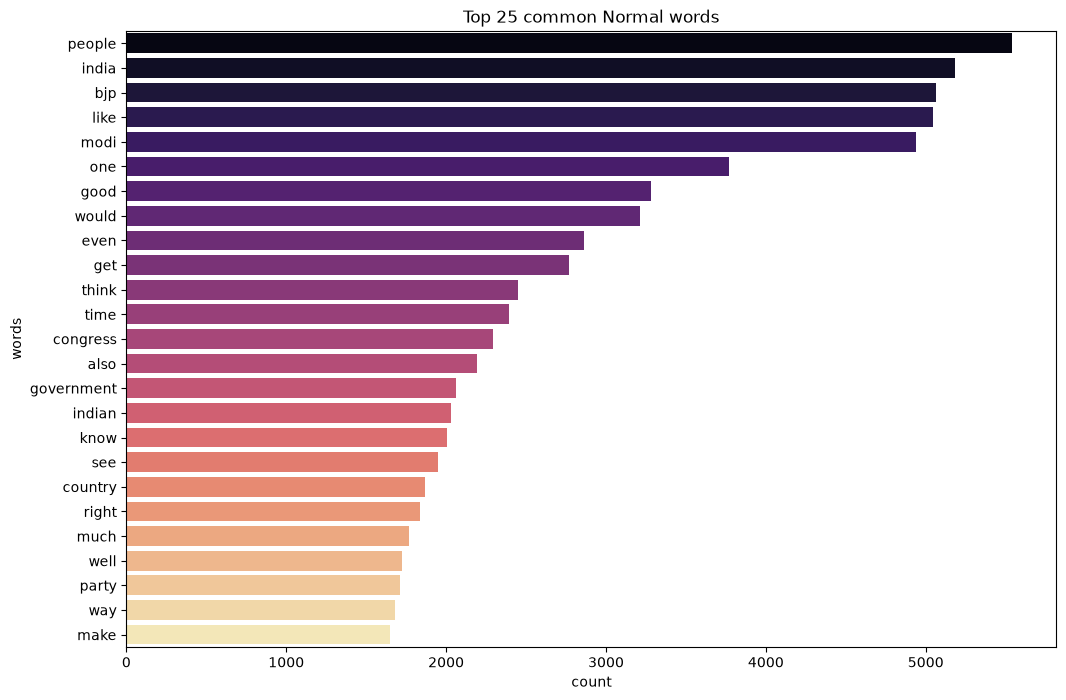

In [38]:
all_normal_words = [word for comment in df["clean_comment"] for word in comment.split() if word not in STOPWORDS]

most_25_common_normal_words = Counter(all_normal_words).most_common(25)
top_25words_df = pd.DataFrame(most_25_common_normal_words, columns= ["words","count"])

plt.figure(figsize=(12,8))
sns.barplot(top_25words_df, x= "count", y="words",palette="magma")
plt.title("Top 25 common Normal words")
plt.show()

In [39]:
def num_chars(comment):
   return len(comment) 

In [40]:
df["num_chars"] = df["clean_comment"].apply(num_chars)

In [41]:
## remove punctuation
df["clean_comment"] = df["clean_comment"].apply(lambda x : re.sub(r'[^A-Za-z0-9\s!?].,]','',str(x)))

In [42]:
## remove stopwords
df["clean_comment"] = df["clean_comment"].apply(lambda x: ' '.join([word for word in x.split() if word not in STOPWORDS]))

In [43]:
df.head()

,clean_comment,category,word_count,num_stopwords,num_chars
0,family mormon never tried explain still stare ...,1,39,13,259
1,buddhism much lot compatible christianity espe...,1,196,59,1268
2,seriously say thing first get complex explain ...,-1,86,40,459
3,learned want teach different focus goal wrappi...,0,29,15,167
4,benefit may want read living buddha living chr...,1,112,45,690


In [48]:
# Lemmatization is better than stemming for finding the correct grammatical base form
# because it uses a dictionary (WordNet) and considers the word's context/POS.

## Lemmatization
from nltk.stem import WordNetLemmatizer
nltk.download("wordnet")

lemmatizer = WordNetLemmatizer()
df["clean_comment"] = df["clean_comment"].apply(lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()]))

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\SAYAN\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [49]:
df.head()

,clean_comment,category,word_count,num_stopwords,num_chars
0,family mormon never tried explain still stare ...,1,39,13,259
1,buddhism much lot compatible christianity espe...,1,196,59,1268
2,seriously say thing first get complex explain ...,-1,86,40,459
3,learned want teach different focus goal wrappi...,0,29,15,167
4,benefit may want read living buddha living chr...,1,112,45,690


In [51]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


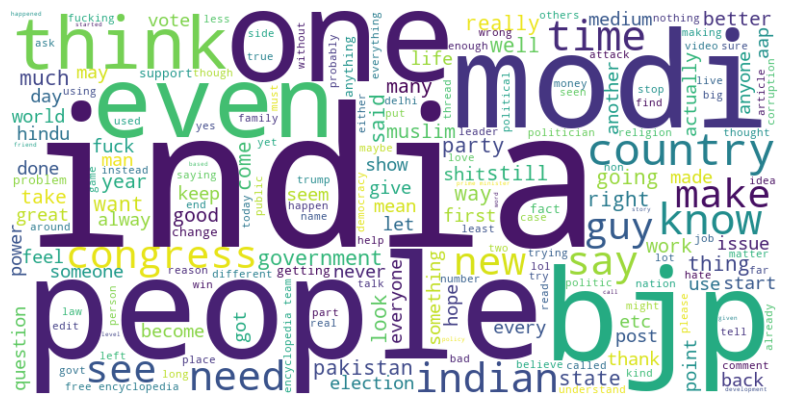

In [54]:
from wordcloud import WordCloud

def plot_wordcloud(text):
        wordcloud = WordCloud(width=800, height=400, background_color="white").generate(' '.join(text))
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation="bilinear")
        plt.axis("off")  # Removes the X and Y axes ticks
        plt.show()

plot_wordcloud(df["clean_comment"])